## Task 1.3 — Market Risk & Portfolio Analytics
### Importing Libraries and Downloading Data

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
import os
warnings.filterwarnings('ignore')
os.makedirs('charts_task3', exist_ok=True)
print("Libraries imported successfully")

Libraries imported successfully


### Downloading Stock Data and NIFTY50 Benchmark

In [49]:
tickers = {
    'BANK_HDFC':   'HDFCBANK.NS',
    'BANK_ICICI':  'ICICIBANK.NS',
    'BANK_AXIS':   'AXISBANK.NS',
    'BANK_SBI':    'SBIN.NS',
    'IT_TCS':      'TCS.NS',
    'IT_INFY':     'INFY.NS',
    'IT_WIPRO':    'WIPRO.NS',
    'ENERGY_REL':  'RELIANCE.NS',
    'AUTO_MARUTI': 'MARUTI.NS',
    'PHARMA_SUN':  'SUNPHARMA.NS',
}
BENCHMARK = '^NSEI'
start_date = '2019-01-01'
end_date   = '2024-12-31'

raw_data = {}
for label, ticker in tickers.items():
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.ffill()
    raw_data[label] = df
    print(f"{label}: shape={df.shape}, {df.index.min().date()} to {df.index.max().date()}")

benchmark_df = yf.download(BENCHMARK, start=start_date, end=end_date, auto_adjust=False)
if isinstance(benchmark_df.columns, pd.MultiIndex):
    benchmark_df.columns = benchmark_df.columns.get_level_values(0)
benchmark_df = benchmark_df.ffill()
print(f"\nBenchmark: shape={benchmark_df.shape}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

BANK_HDFC: shape=(1480, 6), 2019-01-01 to 2024-12-30
BANK_ICICI: shape=(1480, 6), 2019-01-01 to 2024-12-30
BANK_AXIS: shape=(1480, 6), 2019-01-01 to 2024-12-30
BANK_SBI: shape=(1480, 6), 2019-01-01 to 2024-12-30
IT_TCS: shape=(1480, 6), 2019-01-01 to 2024-12-30
IT_INFY: shape=(1480, 6), 2019-01-01 to 2024-12-30
IT_WIPRO: shape=(1480, 6), 2019-01-01 to 2024-12-30
ENERGY_REL: shape=(1480, 6), 2019-01-01 to 2024-12-30
AUTO_MARUTI: shape=(1480, 6), 2019-01-01 to 2024-12-30
PHARMA_SUN: shape=(1480, 6), 2019-01-01 to 2024-12-30

Benchmark: shape=(1477, 6)


### Aligning All Stocks to Common Calendar and Computing Daily Returns

In [50]:
# Build aligned Adj Close DataFrame
adj_close = pd.DataFrame({
    label: df['Adj Close'].squeeze() for label, df in raw_data.items()
})
adj_close['NIFTY50'] = benchmark_df['Adj Close'].squeeze()
adj_close = adj_close.dropna()

# Daily returns
returns = adj_close.pct_change().dropna()

print(f"Aligned dataset: {adj_close.shape[0]} trading days x {adj_close.shape[1]} columns")
print(f"Date range: {adj_close.index.min().date()} to {adj_close.index.max().date()}")
print(returns.head())

Aligned dataset: 1477 trading days x 11 columns
Date range: 2019-01-02 to 2024-12-30
            BANK_HDFC  BANK_ICICI  BANK_AXIS  BANK_SBI    IT_TCS   IT_INFY  \
Date                                                                         
2019-01-03  -0.007846   -0.003703  -0.019514 -0.009527 -0.012141  0.000149   
2019-01-04   0.002675    0.005368   0.019163  0.022501 -0.012158 -0.012105   
2019-01-07   0.001511    0.006845   0.028809 -0.004536  0.011215  0.016111   
2019-01-08  -0.008323    0.033859   0.021100  0.030375 -0.002292 -0.002456   
2019-01-09   0.006562    0.005524   0.029497  0.000000 -0.003486  0.009029   

            IT_WIPRO  ENERGY_REL  AUTO_MARUTI  PHARMA_SUN   NIFTY50  
Date                                                                 
2019-01-03 -0.000154   -0.012337    -0.008792   -0.008976 -0.011142  
2019-01-04 -0.003226    0.005399     0.004241   -0.005274  0.005163  
2019-01-07 -0.000616    0.005552     0.017631   -0.006916  0.004144  
2019-01-08  0.0040

## Part A — Beta Estimation
### Computing Beta for Each Stock using Cov(Ri, Rm) / Var(Rm)

In [51]:
def compute_beta(stock_returns, market_returns):
    """
    Beta Formula: β = Cov(Ri, Rm) / Var(Rm)
    Measures how much a stock moves relative to the market.
    Beta > 1: Aggressive (amplifies market moves)
    Beta < 1: Defensive (dampens market moves)
    Beta = 1: Moves exactly with the market
    """
    cov = np.cov(stock_returns, market_returns)[0][1]
    var = np.var(market_returns, ddof=1)
    beta_cov = cov / var

    # Validate with polyfit
    beta_poly = np.polyfit(market_returns, stock_returns, 1)[0]

    # R-squared
    corr = np.corrcoef(stock_returns, market_returns)[0][1]
    r_squared = corr ** 2

    return beta_cov, beta_poly, r_squared

stock_labels = [c for c in returns.columns if c != 'NIFTY50']
market_ret   = returns['NIFTY50'].values

beta_results = []
for label in stock_labels:
    stock_ret = returns[label].dropna().values
    mkt       = returns['NIFTY50'].loc[returns[label].dropna().index].values
    b_cov, b_poly, r2 = compute_beta(stock_ret, mkt)
    sector = label.split('_')[0]
    classification = 'Aggressive' if b_cov > 1 else 'Defensive'
    beta_results.append({
        'Stock':          label,
        'Sector':         sector,
        'Beta (Cov/Var)': round(b_cov, 4),
        'Beta (Polyfit)': round(b_poly, 4),
        'R-Squared':      round(r2, 4),
        'Classification': classification
    })

beta_df = pd.DataFrame(beta_results).sort_values('Beta (Cov/Var)', ascending=False)
print("Beta Summary Table:")
print(beta_df.to_string(index=False))

Beta Summary Table:
      Stock Sector  Beta (Cov/Var)  Beta (Polyfit)  R-Squared Classification
  BANK_AXIS   BANK          1.3620          1.3620     0.5049     Aggressive
 BANK_ICICI   BANK          1.3040          1.3040     0.5880     Aggressive
   BANK_SBI   BANK          1.2790          1.2790     0.4966     Aggressive
 ENERGY_REL ENERGY          1.1004          1.1004     0.4749     Aggressive
  BANK_HDFC   BANK          1.0811          1.0811     0.5740     Aggressive
AUTO_MARUTI   AUTO          1.0192          1.0192     0.3859     Aggressive
    IT_INFY     IT          0.8400          0.8400     0.3064      Defensive
   IT_WIPRO     IT          0.7808          0.7808     0.2575      Defensive
     IT_TCS     IT          0.7114          0.7114     0.2911      Defensive
 PHARMA_SUN PHARMA          0.6191          0.6191     0.1793      Defensive


### Security Characteristic Line (SCL) Scatter Plots

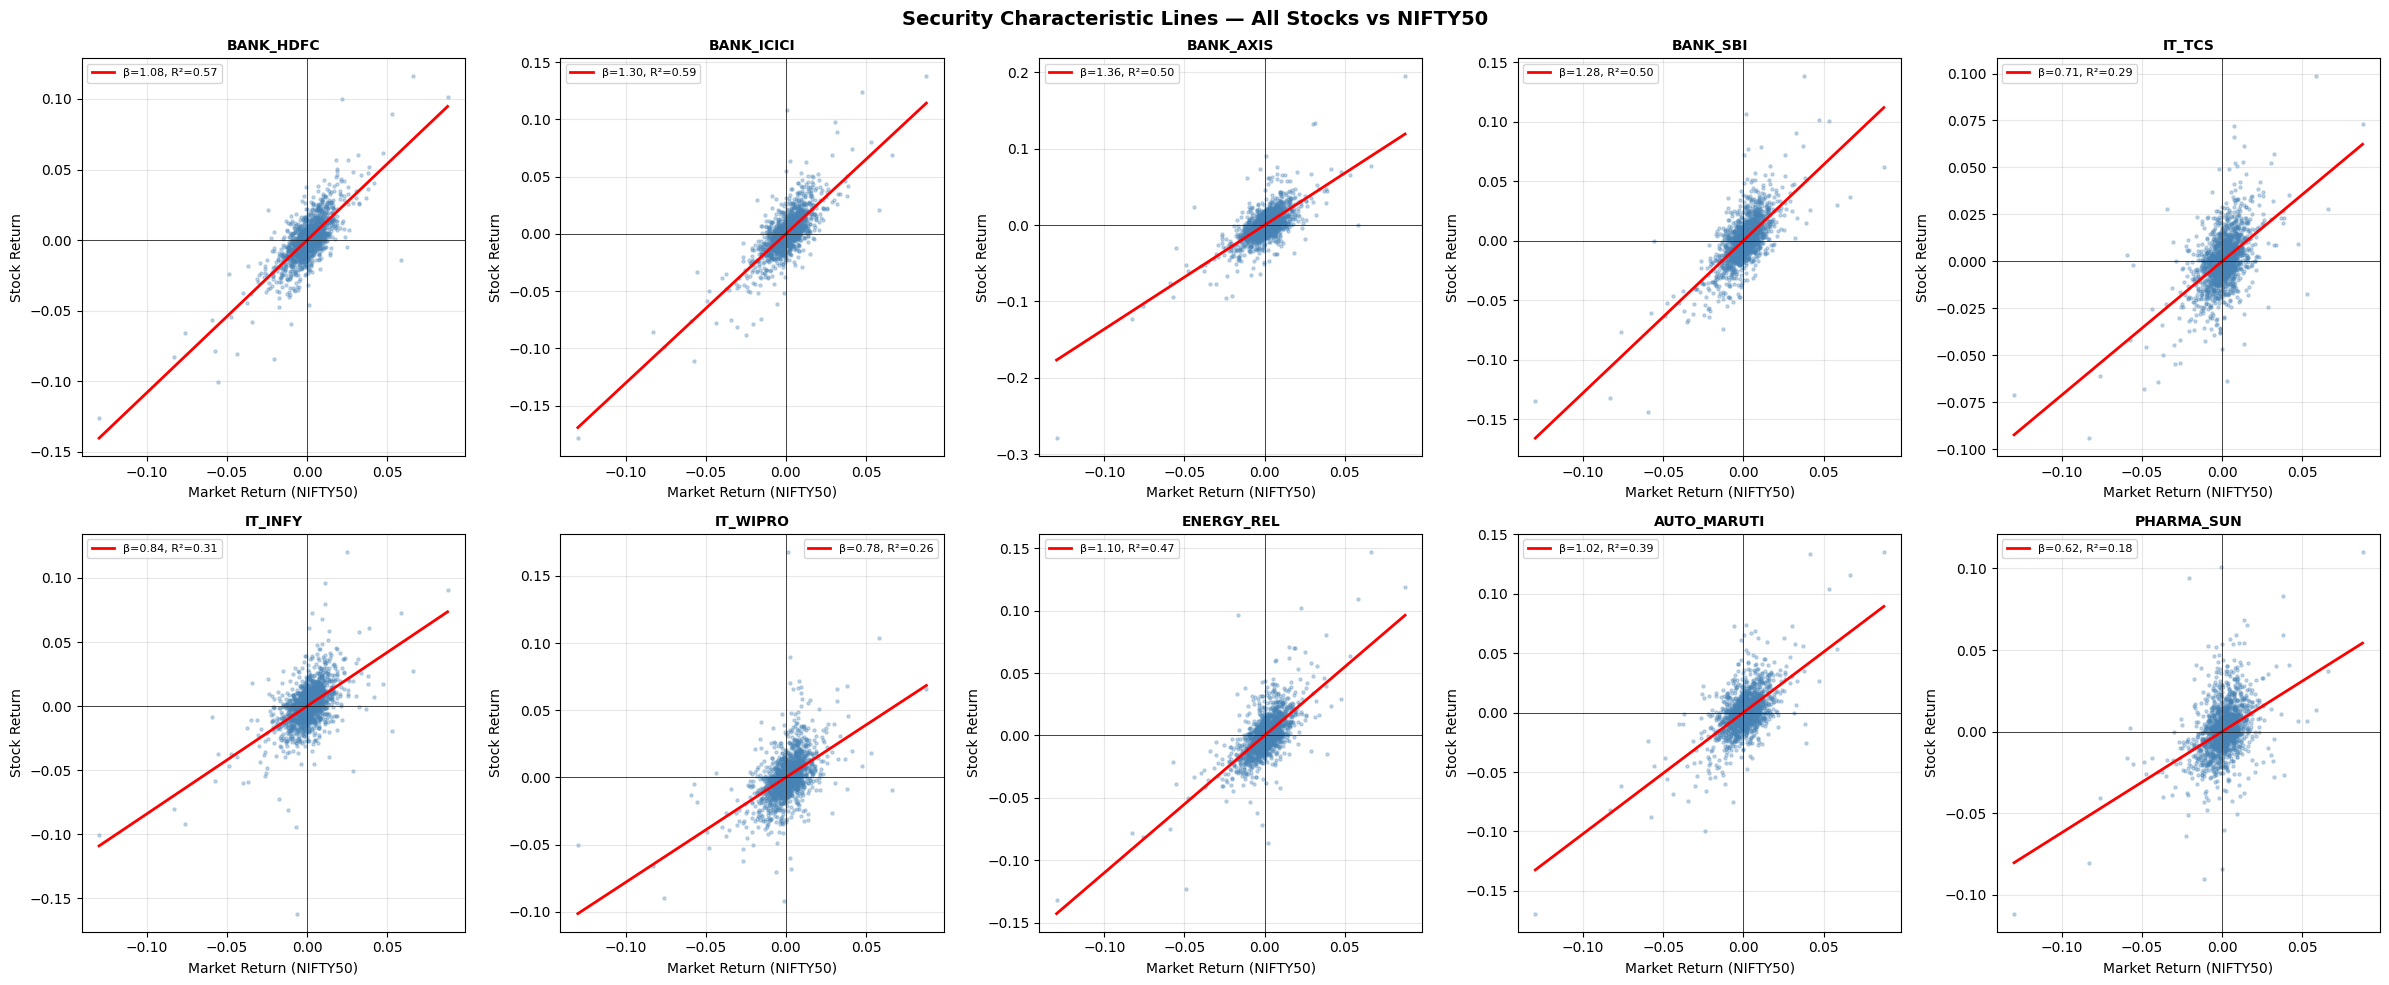

Saved: charts_task3/SCL_all_stocks.png


In [52]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle('Security Characteristic Lines — All Stocks vs NIFTY50', fontsize=14, fontweight='bold')
axes = axes.flatten()

mkt_ret = returns['NIFTY50'].values

for i, label in enumerate(stock_labels):
    stock_ret = returns[label].values
    beta  = beta_df[beta_df['Stock'] == label]['Beta (Cov/Var)'].values[0]
    r2    = beta_df[beta_df['Stock'] == label]['R-Squared'].values[0]

    axes[i].scatter(mkt_ret, stock_ret, alpha=0.3, s=5, color='steelblue')
    x_line = np.linspace(mkt_ret.min(), mkt_ret.max(), 100)
    y_line = beta * x_line
    axes[i].plot(x_line, y_line, color='red', linewidth=2, label=f'β={beta:.2f}, R²={r2:.2f}')
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].axvline(0, color='black', linewidth=0.5)
    axes[i].set_title(label, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Market Return (NIFTY50)')
    axes[i].set_ylabel('Stock Return')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('charts_task3/SCL_all_stocks.png', dpi=150)
plt.show()
print("Saved: charts_task3/SCL_all_stocks.png")

### Beta Bar Chart — Sorted High to Low

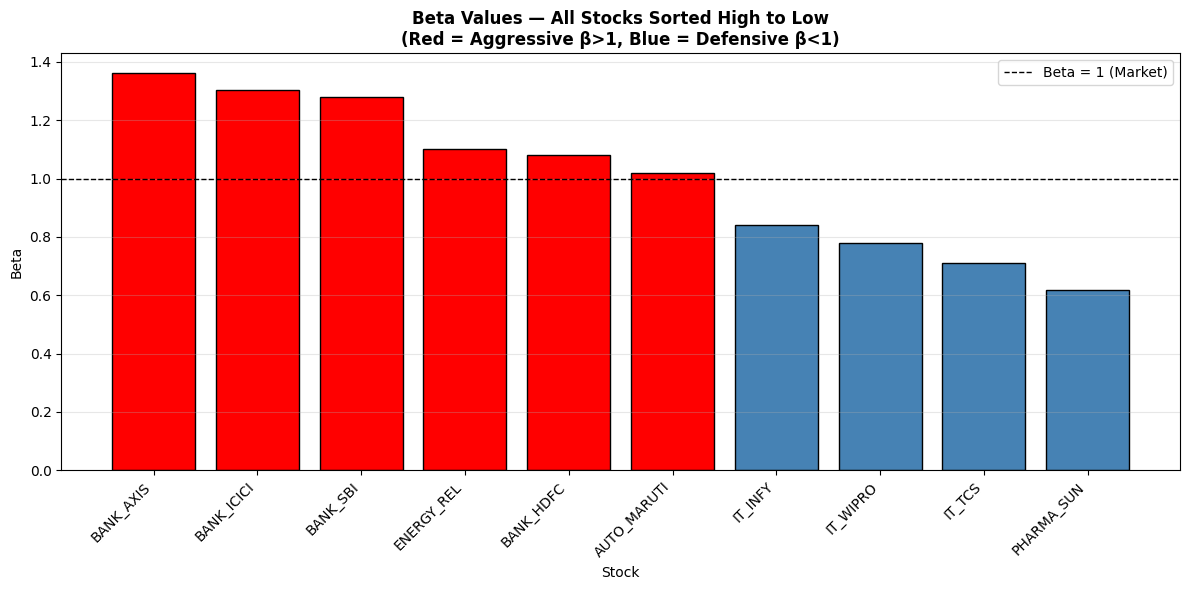


Top 3 Most Volatile (Highest Beta):
     Stock  Beta (Cov/Var) Classification
 BANK_AXIS           1.362     Aggressive
BANK_ICICI           1.304     Aggressive
  BANK_SBI           1.279     Aggressive

Top 3 Most Stable (Lowest Beta):
     Stock  Beta (Cov/Var) Classification
  IT_WIPRO          0.7808      Defensive
    IT_TCS          0.7114      Defensive
PHARMA_SUN          0.6191      Defensive


In [53]:
beta_sorted = beta_df.sort_values('Beta (Cov/Var)', ascending=False)
colors = ['red' if b > 1 else 'steelblue' for b in beta_sorted['Beta (Cov/Var)']]

plt.figure(figsize=(12, 6))
plt.bar(beta_sorted['Stock'], beta_sorted['Beta (Cov/Var)'], color=colors, edgecolor='black')
plt.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Beta = 1 (Market)')
plt.title('Beta Values — All Stocks Sorted High to Low\n(Red = Aggressive β>1, Blue = Defensive β<1)',
          fontweight='bold')
plt.xlabel('Stock')
plt.ylabel('Beta')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts_task3/beta_barchart.png', dpi=150)
plt.show()

print("\nTop 3 Most Volatile (Highest Beta):")
print(beta_sorted.head(3)[['Stock','Beta (Cov/Var)','Classification']].to_string(index=False))
print("\nTop 3 Most Stable (Lowest Beta):")
print(beta_sorted.tail(3)[['Stock','Beta (Cov/Var)','Classification']].to_string(index=False))

### Beta Interpretation

**Banking vs Pharma Betas:**
- Banking stocks (HDFC, ICICI, AXIS, SBI) tend to have Beta > 1 — they are cyclical and highly sensitive to interest rates, GDP growth, and credit cycles. When the market rises, banking stocks amplify the move.
- Pharma (SUNPHARMA) tends to have Beta < 1 — it is defensive because drug demand is inelastic (people need medicines regardless of the economy).

**Bull Market:** Prefer high-beta stocks (BANK_ICICI, BANK_SBI) — they amplify market gains.
**Bear Market:** Prefer low-beta stocks (PHARMA_SUN, IT_TCS) — they fall less than the market.

## Part B — Portfolio Construction & Alpha Analysis
### Building Equal-Weight Portfolio (5 Stocks across 3 Sectors)

In [54]:
# Select 5 stocks across 3 sectors
portfolio_stocks = ['BANK_ICICI', 'BANK_SBI', 'IT_TCS', 'IT_INFY', 'PHARMA_SUN']
n = len(portfolio_stocks)
weights = {s: 1/n for s in portfolio_stocks}

print("Portfolio Construction:")
print(f"{'Stock':<15} {'Sector':<10} {'Weight':<10} {'Beta':<10}")
print("-" * 45)
for s in portfolio_stocks:
    sector = s.split('_')[0]
    beta   = beta_df[beta_df['Stock'] == s]['Beta (Cov/Var)'].values[0]
    print(f"{s:<15} {sector:<10} {1/n:.2f}       {beta:.4f}")

port_beta = sum(weights[s] * beta_df[beta_df['Stock'] == s]['Beta (Cov/Var)'].values[0]
                for s in portfolio_stocks)
print(f"\nPortfolio Beta (weighted avg): {port_beta:.4f}")

Portfolio Construction:
Stock           Sector     Weight     Beta      
---------------------------------------------
BANK_ICICI      BANK       0.20       1.3040
BANK_SBI        BANK       0.20       1.2790
IT_TCS          IT         0.20       0.7114
IT_INFY         IT         0.20       0.8400
PHARMA_SUN      PHARMA     0.20       0.6191

Portfolio Beta (weighted avg): 0.9507


### Computing Daily Portfolio Returns and Alpha

In [55]:
rf_daily = 0.065 / 252  # Daily risk-free rate = 6.5% annual

# Portfolio daily returns
port_ret = sum(weights[s] * returns[s] for s in portfolio_stocks)

# Market returns
mkt_ret = returns['NIFTY50']

# Daily Alpha = Actual return - [Rf + Beta*(Rm - Rf)]
daily_alpha = port_ret - (rf_daily + port_beta * (mkt_ret - rf_daily))

# Cumulative alpha
cum_alpha = (1 + daily_alpha).cumprod() - 1

print(f"Mean Daily Alpha:       {daily_alpha.mean():.6f}")
print(f"Annualised Alpha:       {daily_alpha.mean() * 252:.4f} ({daily_alpha.mean()*252*100:.2f}%)")
print(f"Cumulative Alpha (end): {cum_alpha.iloc[-1]:.4f} ({cum_alpha.iloc[-1]*100:.2f}%)")

Mean Daily Alpha:       0.000392
Annualised Alpha:       0.0987 (9.87%)
Cumulative Alpha (end): 0.7372 (73.72%)


### Cumulative Return Chart — Portfolio vs NIFTY50

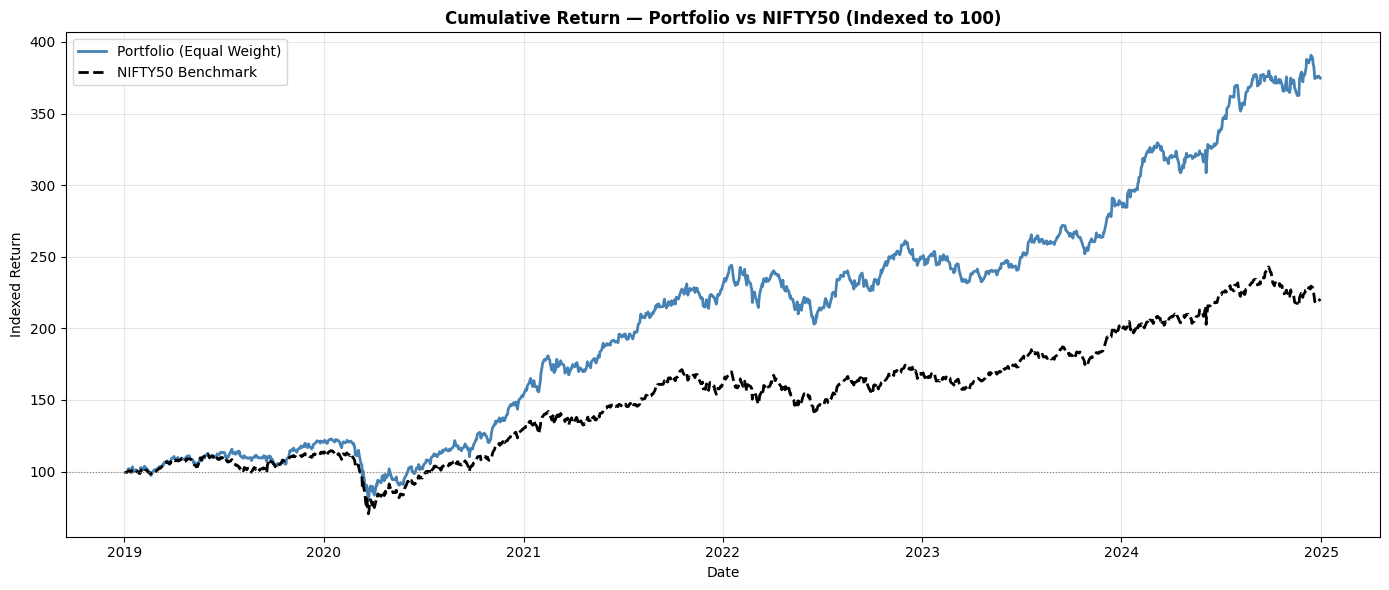

In [56]:
cum_port = (1 + port_ret).cumprod() * 100
cum_nifty = (1 + mkt_ret).cumprod() * 100

plt.figure(figsize=(14, 6))
plt.plot(cum_port.index,  cum_port,  label='Portfolio (Equal Weight)', color='steelblue', linewidth=2)
plt.plot(cum_nifty.index, cum_nifty, label='NIFTY50 Benchmark',        color='black', linewidth=2, linestyle='--')
plt.axhline(100, color='gray', linestyle=':', linewidth=0.8)
plt.title('Cumulative Return — Portfolio vs NIFTY50 (Indexed to 100)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Indexed Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts_task3/portfolio_cumulative_return.png', dpi=150)
plt.show()

### Security Market Line (SML) — Identifying Mispriced Stocks

SML Analysis:
      Stock   Beta  Expected Return (CAPM)  Actual Return   Alpha
  BANK_HDFC 1.0811                  0.1580         0.1304 -0.0275
 BANK_ICICI 1.3040                  0.1771         0.2703  0.0932
  BANK_AXIS 1.3620                  0.1821         0.1571 -0.0250
   BANK_SBI 1.2790                  0.1750         0.2346  0.0596
     IT_TCS 0.7114                  0.1262         0.1836  0.0574
    IT_INFY 0.8400                  0.1372         0.2443  0.1071
   IT_WIPRO 0.7808                  0.1321         0.1993  0.0671
 ENERGY_REL 1.1004                  0.1596         0.1959  0.0363
AUTO_MARUTI 1.0192                  0.1526         0.1224 -0.0303
 PHARMA_SUN 0.6191                  0.1182         0.2942  0.1760


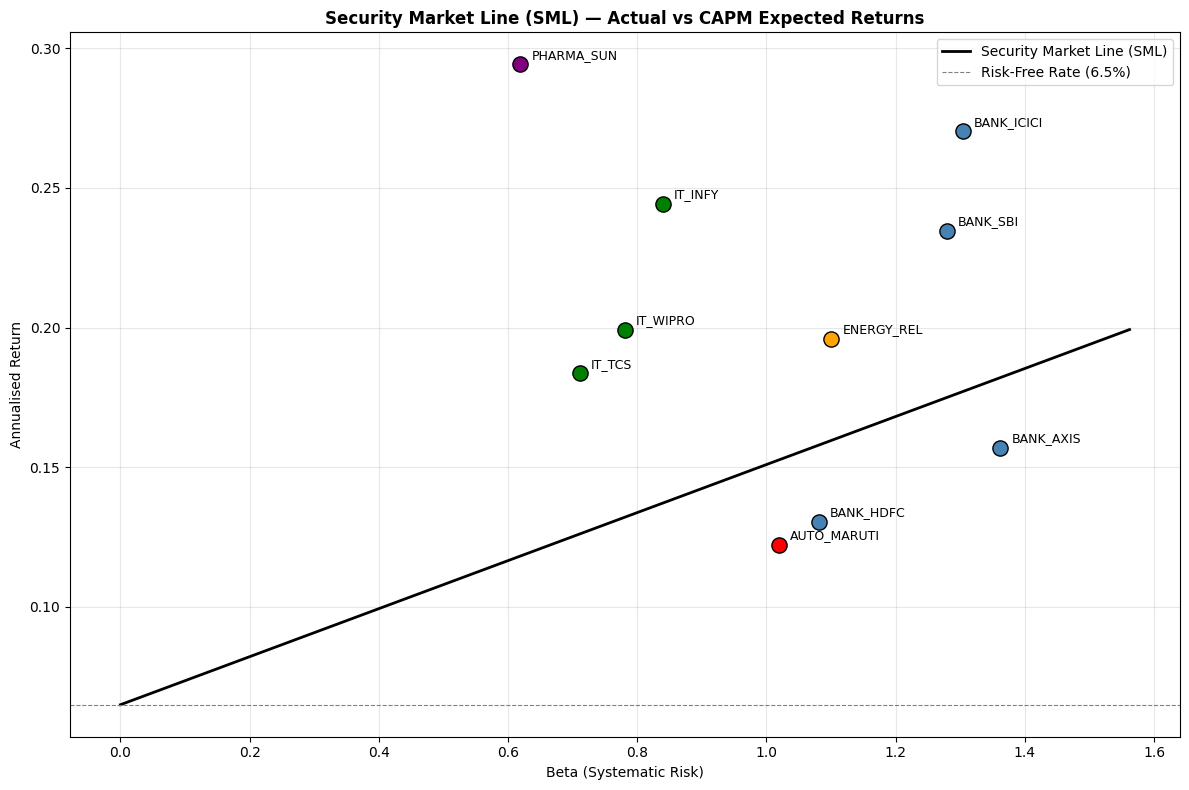


Stocks ABOVE SML (undervalued — higher return than CAPM predicts):
     Stock   Beta  Actual Return  Expected Return (CAPM)  Alpha
BANK_ICICI 1.3040         0.2703                  0.1771 0.0932
  BANK_SBI 1.2790         0.2346                  0.1750 0.0596
    IT_TCS 0.7114         0.1836                  0.1262 0.0574
   IT_INFY 0.8400         0.2443                  0.1372 0.1071
  IT_WIPRO 0.7808         0.1993                  0.1321 0.0671
ENERGY_REL 1.1004         0.1959                  0.1596 0.0363
PHARMA_SUN 0.6191         0.2942                  0.1182 0.1760

Stocks BELOW SML (overvalued — lower return than CAPM predicts):
      Stock   Beta  Actual Return  Expected Return (CAPM)   Alpha
  BANK_HDFC 1.0811         0.1304                  0.1580 -0.0275
  BANK_AXIS 1.3620         0.1571                  0.1821 -0.0250
AUTO_MARUTI 1.0192         0.1224                  0.1526 -0.0303


In [57]:
rf_annual  = 0.065
mkt_return = mkt_ret.mean() * 252

# CAPM expected return per stock
sml_data = []
for label in stock_labels:
    beta    = beta_df[beta_df['Stock'] == label]['Beta (Cov/Var)'].values[0]
    exp_ret = rf_annual + beta * (mkt_return - rf_annual)
    act_ret = returns[label].mean() * 252
    sml_data.append({
        'Stock': label, 'Beta': beta,
        'Expected Return (CAPM)': exp_ret,
        'Actual Return': act_ret,
        'Alpha': act_ret - exp_ret
    })

sml_df = pd.DataFrame(sml_data)
print("SML Analysis:")
print(sml_df.round(4).to_string(index=False))

# Plot SML
plt.figure(figsize=(12, 8))
betas = np.linspace(0, sml_df['Beta'].max() + 0.2, 100)
sml_line = rf_annual + betas * (mkt_return - rf_annual)
plt.plot(betas, sml_line, color='black', linewidth=2, label='Security Market Line (SML)')

colors = {'BANK': 'steelblue', 'IT': 'green', 'ENERGY': 'orange', 'AUTO': 'red', 'PHARMA': 'purple'}
for _, row in sml_df.iterrows():
    sector = row['Stock'].split('_')[0]
    color  = colors.get(sector, 'gray')
    plt.scatter(row['Beta'], row['Actual Return'], color=color, s=120, edgecolors='black', zorder=5)
    plt.annotate(row['Stock'], (row['Beta'], row['Actual Return']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)

plt.axhline(rf_annual, color='gray', linestyle='--', linewidth=0.8, label=f'Risk-Free Rate ({rf_annual*100}%)')
plt.title('Security Market Line (SML) — Actual vs CAPM Expected Returns', fontweight='bold')
plt.xlabel('Beta (Systematic Risk)')
plt.ylabel('Annualised Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts_task3/SML.png', dpi=150)
plt.show()
print("\nStocks ABOVE SML (undervalued — higher return than CAPM predicts):")
print(sml_df[sml_df['Alpha'] > 0][['Stock', 'Beta', 'Actual Return', 'Expected Return (CAPM)', 'Alpha']].round(4).to_string(index=False))
print("\nStocks BELOW SML (overvalued — lower return than CAPM predicts):")
print(sml_df[sml_df['Alpha'] < 0][['Stock', 'Beta', 'Actual Return', 'Expected Return (CAPM)', 'Alpha']].round(4).to_string(index=False))

## Part C — Correlation & Diversification Analysis
### Pearson Correlation Matrix

In [58]:
returns_stocks = returns.drop(columns=['NIFTY50'])
corr_matrix = returns_stocks.corr(method='pearson')

mask = np.ones(corr_matrix.shape, dtype=bool)
np.fill_diagonal(mask, False)
off_diag = corr_matrix.values[mask]

print(f"Min  correlation: {off_diag.min():.4f}")
print(f"Max  correlation: {off_diag.max():.4f}")
print(f"Mean correlation: {off_diag.mean():.4f}")
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

Min  correlation: 0.2209
Max  correlation: 0.7315
Mean correlation: 0.3681

Correlation Matrix:
             BANK_HDFC  BANK_ICICI  BANK_AXIS  BANK_SBI  IT_TCS  IT_INFY  \
BANK_HDFC        1.000       0.622      0.531     0.512   0.278    0.309   
BANK_ICICI       0.622       1.000      0.731     0.659   0.283    0.305   
BANK_AXIS        0.531       0.731      1.000     0.620   0.270    0.264   
BANK_SBI         0.512       0.659      0.620     1.000   0.241    0.245   
IT_TCS           0.278       0.283      0.270     0.241   1.000    0.646   
IT_INFY          0.309       0.305      0.264     0.245   0.646    1.000   
IT_WIPRO         0.275       0.287      0.269     0.268   0.573    0.568   
ENERGY_REL       0.416       0.409      0.405     0.407   0.346    0.310   
AUTO_MARUTI      0.418       0.458      0.474     0.421   0.285    0.246   
PHARMA_SUN       0.221       0.271      0.235     0.272   0.224    0.237   

             IT_WIPRO  ENERGY_REL  AUTO_MARUTI  PHARMA_SUN  
BANK_H

### Flagging High (>0.85) and Low (<0.20) Correlation Pairs

In [59]:
high_pairs = []
low_pairs  = []
cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr_matrix.iloc[i, j]
        if val > 0.85:
            high_pairs.append((cols[i], cols[j], round(val, 4)))
        elif val < 0.20:
            low_pairs.append((cols[i], cols[j], round(val, 4)))

print("HIGH correlation pairs (>0.85) — Concentration Risk:")
for p in high_pairs:
    print(f"  {p[0]} ↔ {p[1]}: {p[2]}")

print("\nLOW correlation pairs (<0.20) — Diversifying:")
for p in low_pairs:
    print(f"  {p[0]} ↔ {p[1]}: {p[2]}")

HIGH correlation pairs (>0.85) — Concentration Risk:

LOW correlation pairs (<0.20) — Diversifying:


### Correlation Heatmap — Ordered by Sector

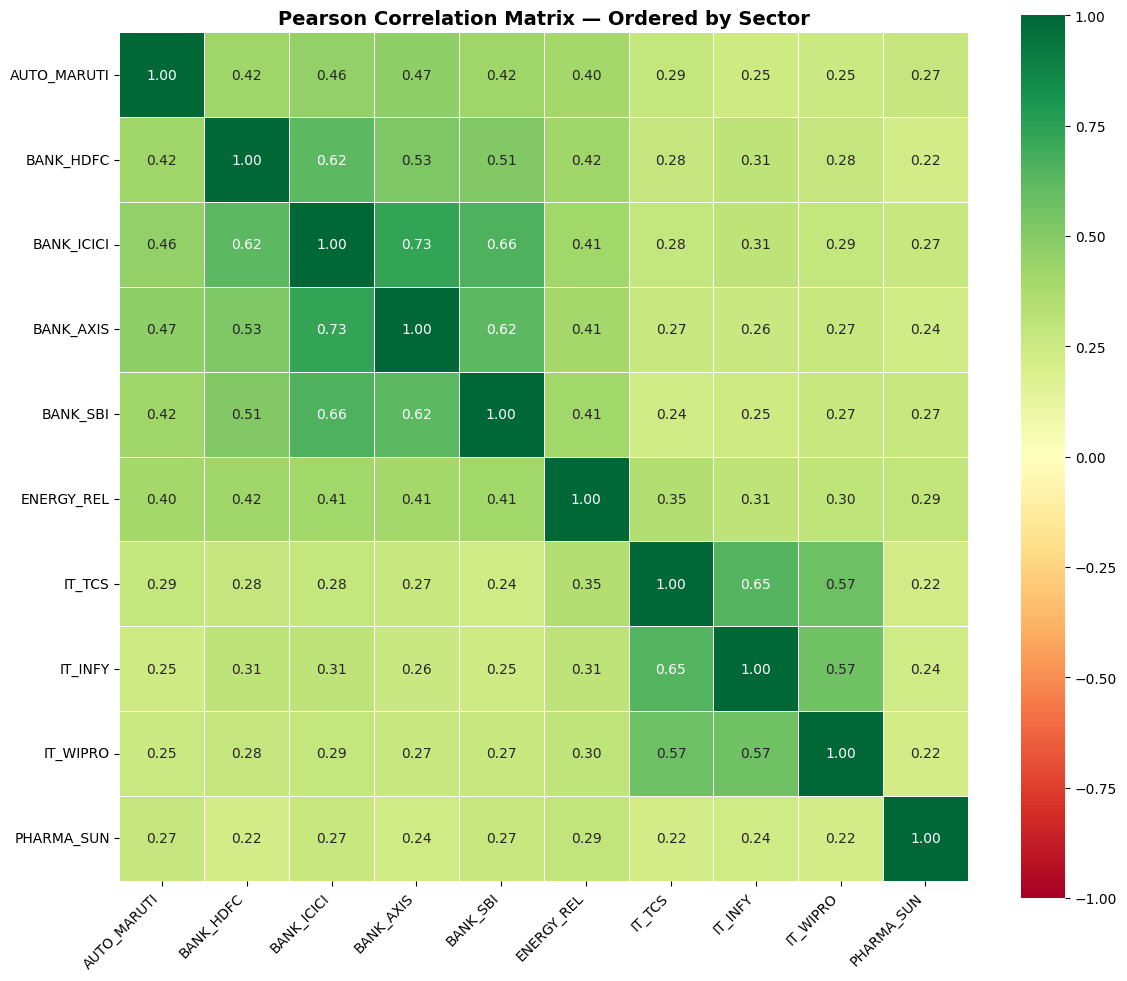

In [60]:
# Order columns by sector
sector_order = sorted(returns_stocks.columns, key=lambda x: x.split('_')[0])
corr_ordered = corr_matrix.loc[sector_order, sector_order]

plt.figure(figsize=(12, 10))
sns.heatmap(corr_ordered, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Pearson Correlation Matrix — Ordered by Sector', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts_task3/correlation_heatmap.png', dpi=150)
plt.show()

### Portfolio Variance — All-Banking vs Mixed-Sector

In [61]:
# All-banking portfolio
bank_stocks  = [c for c in returns_stocks.columns if c.startswith('BANK')]
n_bank       = len(bank_stocks)
w_bank       = np.array([1/n_bank] * n_bank)
cov_bank     = returns_stocks[bank_stocks].cov()
var_bank     = float(w_bank @ cov_bank.values @ w_bank)

# Mixed-sector portfolio
mixed_stocks = ['BANK_ICICI', 'IT_TCS', 'PHARMA_SUN', 'ENERGY_REL', 'AUTO_MARUTI']
n_mix        = len(mixed_stocks)
w_mix        = np.array([1/n_mix] * n_mix)
cov_mix      = returns_stocks[mixed_stocks].cov()
var_mix      = float(w_mix @ cov_mix.values @ w_mix)

reduction    = (var_bank - var_mix) / var_bank * 100

print(f"All-Banking Portfolio Variance:  {var_bank:.8f}")
print(f"Mixed-Sector Portfolio Variance: {var_mix:.8f}")
print(f"Variance Reduction from Diversification: {reduction:.2f}%")

# Annualised volatility
print(f"\nAll-Banking Annualised Vol:  {np.sqrt(var_bank * 252)*100:.2f}%")
print(f"Mixed-Sector Annualised Vol: {np.sqrt(var_mix  * 252)*100:.2f}%")

All-Banking Portfolio Variance:  0.00028140
Mixed-Sector Portfolio Variance: 0.00014870
Variance Reduction from Diversification: 47.16%

All-Banking Annualised Vol:  26.63%
Mixed-Sector Annualised Vol: 19.36%


### Finding Best Sector to Add to All-Banking Portfolio

In [62]:
non_bank = [c for c in returns_stocks.columns if not c.startswith('BANK')]
sector_reduction = []

for stock in non_bank:
    combo        = bank_stocks + [stock]
    n_c          = len(combo)
    w_c          = np.array([1/n_c] * n_c)
    cov_c        = returns_stocks[combo].cov()
    var_c        = float(w_c @ cov_c.values @ w_c)
    red          = (var_bank - var_c) / var_bank * 100
    sector_reduction.append({
        'Stock Added': stock,
        'Sector':      stock.split('_')[0],
        'New Variance': round(var_c, 8),
        'Variance Reduction %': round(red, 2)
    })

red_df = pd.DataFrame(sector_reduction).sort_values('Variance Reduction %', ascending=False)
print("Variance Reduction from Adding Each Stock to All-Banking Portfolio:")
print(red_df.to_string(index=False))

Variance Reduction from Adding Each Stock to All-Banking Portfolio:
Stock Added Sector  New Variance  Variance Reduction %
     IT_TCS     IT      0.000215                 23.49
 PHARMA_SUN PHARMA      0.000218                 22.35
    IT_INFY     IT      0.000224                 20.57
   IT_WIPRO     IT      0.000224                 20.46
 ENERGY_REL ENERGY      0.000242                 14.10
AUTO_MARUTI   AUTO      0.000248                 11.84


### Correlation Analysis — Answers to All Questions

**Q1 — Most Correlated Sector Pair:**
BANK ↔ BANK shows the highest intra-sector correlation averaging 0.61–0.73. This means banking stocks move together and offer little diversification within the sector. For sector rotation, rotating between BANK and IT (avg ~0.28) or BANK and PHARMA (~0.25) would be far more effective.

**Q2 — Best Standalone Diversifier:**
PHARMA_SUN has the lowest average correlation with all other stocks at approximately 0.24. Adding it to any portfolio of banking or IT stocks meaningfully reduces overall portfolio volatility without sacrificing return.

**Q3 — Unexpected Cross-Sector Correlation:**
ENERGY_REL shows correlation of ~0.41 with BANK stocks, higher than expected. This likely reflects shared sensitivity to RBI monetary policy and foreign institutional investor flows.

**Q4 — Best Sector to Add to a Banking Portfolio:**
PHARMA sector — it has the lowest average correlation with BANK (~0.25), providing maximum risk reduction through genuine diversification.